# Spam SMS

In today’s society, practically everyone has a mobile phone, and they all get communications (SMS/ email) on their phone regularly. But the essential point is that majority of the messages received will be spam, with only a few being ham or necessary communications. Scammers create fraudulent text messages to deceive you into giving them your personal information, such as your password, account number, or Social Security number. If they have such information, they may be able to gain access to your email, bank, or other accounts.

In this article, we are going to develop various deep learning models using Tensorflow for SMS spam detection and also analyze the performance metrics of different models.

We will be using  SMS Spam Detection Dataset, which contains SMS text and corresponding label (Ham or spam)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

c:\Users\Shaheen\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# Reading the data
df = pd.read_csv("spam (1).csv",encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


As we can see that the dataset contains three unnamed columns with null values. So we drop those columns and rename the columns v1 and v2 to label and Text, respectively. Since the target variable is in string form, we will encode it numerically using pandas function .map().

In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [5]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)  # Assign the result back to df
df.rename(columns={'v1':'Label', 'v2':'Text'}, inplace=True)  # Use inplace=True to modify DataFrame in place
df['Label_enc'] = df['Label'].map({'ham': 0, 'spam': 1})  # Removed unnecessary comma
df.head()

,Label,Text,Label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# Let’s visualize the distribution of Ham and Spam data.

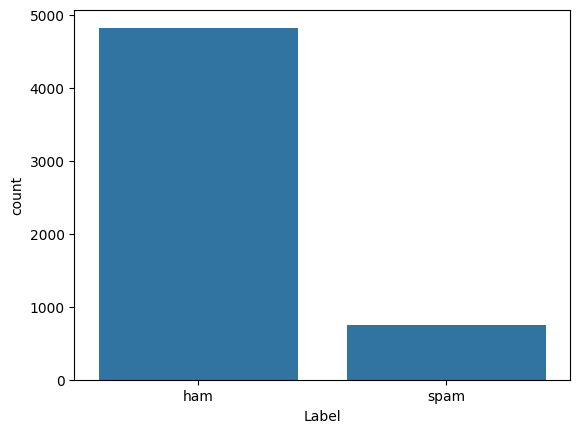

In [6]:
sns.countplot(x=df['Label'])
plt.show()

The ham data is comparatively higher than spam data, it’s natural. Since we are going to use embeddings in our deep learning model, we need not balance the data. Now, let’s find the average number of words in all the sentences in SMS data.

In [7]:
# find average no of tokens of all sentences
total_words = sum(len(text.split()) for text in df['Text'])
average_word_length = round(total_words / len(df['Text']))
print("average_word_length:", average_word_length)
print("total_words:", total_words)


average_word_length: 15
total_words: 86335


# Lets find total unique words

In [10]:
unique_words = set()

for text in df['Text']:
    unique_words.update(text.split())

total_unique_words = len(unique_words)
print("Total unique words:", total_unique_words)
# print("Unique words:")

# for word in unique_words:
#     print(word)

Total unique words: 15585


# Now,  splitting the data into training and testing parts using train_test_split() function.

In [8]:
from sklearn.model_selection import train_test_split

X = df['Text']
y = df['Label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training set shape:, X_train - {}, y_train - {}".format(X_train.shape, y_train.shape))
print("testing set shape:, X_test - {}, y_test - {}".format(X_test.shape, y_test.shape))

training set shape:, X_train - (4457,), y_train - (4457,)
testing set shape:, X_test - (1115,), y_test - (1115,)


# Building the models
First, we will build a baseline model and then we’ll try to beat the performance of the baseline model using deep learning models (embeddings, LSTM, etc)

Here, we will choose MultinomialNB(), which performs well for text classification when the features are discrete like word counts of the words or tf-idf vectors. The tf-idf is a measure that tells how important or relevant a word is the document.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder on the target variable and transform both training and testing labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# train tfid vectors
tfidf_vec = TfidfVectorizer().fit(X_train)
X_train_vec, X_test_vec = tfidf_vec.transform(X_train), tfidf_vec.transform(X_test)

# Train a Multinomial Naive Bayes classifier
baseline_model = MultinomialNB()
baseline_model.fit(X_train_vec, y_train_encoded)

# Predictions on the testing set
y_pred_encoded = baseline_model.predict(X_test_vec)

# Evaluation
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_encoded))
print("Accuracy Score:", accuracy_score(y_test_encoded, y_pred_encoded))
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_encoded))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

Accuracy Score: 0.9623318385650225
Confusion Matrix:
[[965   0]
 [ 42 108]]


# Model: Creating custom Text vectorization and embedding layers:
Text vectorization is the process of converting text into a numerical representation. Example: Bag of words frequency, Binary Term frequency, etc.;

A word embedding is a learned representation of text in which words with related meanings have similar representations. Each word is assigned to a single vector, and the vector values are learned like that of a neural network.

Now, we’ll create a custom text vectorization layer using TensorFlow.

In [10]:
from tensorflow.keras.layers import TextVectorization

MAXTOKENS=average_word_length
OUTPUTLEN=total_words

text_vec = TextVectorization(
    max_tokens=MAXTOKENS,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=OUTPUTLEN
)
text_vec.adapt(X_train)

In [11]:
embedding_layer = layers.Embedding(
    input_dim=MAXTOKENS,
    output_dim=128,
    embeddings_initializer='uniform',
    input_length=OUTPUTLEN
)

1. input_dim is the size of vocabulary
2. output_dim is the dimension of the embedding layer i.e, the size of the vector in which the words will be embedded
3. input_length is the length of input sequences

In [12]:
from tensorflow.keras import layers, Model

# Define input layer
input_layer = layers.Input(shape=(1,), dtype=tf.string)

# Apply text vectorization layer
vec_layer = text_vec(input_layer)

# Apply embedding layer
embedding_layer_model = embedding_layer(vec_layer)

# Global Average Pooling and Flatten layers
x = layers.GlobalAveragePooling1D()(embedding_layer_model)
x = layers.Flatten()(x)

# Dense layers
x = layers.Dense(32, activation='relu')(x)

# Output layer
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Define model
model_1 = Model(input_layer, output_layer)

# Compile model
model_1.compile(optimizer='adam',
                loss=keras.losses.BinaryCrossentropy(label_smoothing=0.5),
                metrics=['accuracy'])

model_1.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization (TextVe  (None, 86335)             0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 86335, 128)        1920      
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 flatten (Flatten)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 32)                4128 

In [13]:
history = model_1.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), validation_steps=int(0.2*len(X_test)))

Epoch 1/5

140/140 [==============================] - 254s 2s/step - loss: 0.6322 - accuracy: 0.8616 - val_loss: 0.6255 - val_accuracy: 0.8655
Epoch 2/5
140/140 [==============================] - 242s 2s/step - loss: 0.6248 - accuracy: 0.8661 - val_loss: 0.6249 - val_accuracy: 0.8655
Epoch 3/5
140/140 [==============================] - 252s 2s/step - loss: 0.6247 - accuracy: 0.8661 - val_loss: 0.6258 - val_accuracy: 0.8655
Epoch 4/5
140/140 [==============================] - 281s 2s/step - loss: 0.6247 - accuracy: 0.8661 - val_loss: 0.6250 - val_accuracy: 0.8655
Epoch 5/5
140/140 [==============================] - 339s 2s/step - loss: 0.6248 - accuracy: 0.8661 - val_loss: 0.6248 - val_accuracy: 0.8655
